In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_features.csv
/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_classes.csv
/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_edgelist.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

In [3]:
features = pd.read_csv("/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_features.csv", header=None)
classes = pd.read_csv("/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_classes.csv")
edges = pd.read_csv("/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_edgelist.csv")

In [4]:
all_columns = features.columns.tolist()
print(all_columns)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166]


In [5]:
tx_col = [features.columns[0]]
time_col = [features.columns[1]]

feature_cols = features.columns[2:]

print("Transaction ID column:", tx_col)
print("Timestep column:", time_col)
print("Total feature columns:", len(feature_cols))

Transaction ID column: [np.int64(0)]
Timestep column: [np.int64(1)]
Total feature columns: 165


In [6]:
features.columns = ["txId", "timestep"] + [f"f_{i}" for i in range(165)]

print("Features shape:", features.shape)
print("Classes shape:", classes.shape)
print("Edges shape:", edges.shape)

Features shape: (203769, 167)
Classes shape: (203769, 2)
Edges shape: (234355, 2)


In [7]:
# Merge (LEFT JOIN to preserve all nodes)
data = features.merge(classes, on="txId", how="left")

# Fill missing labels
data["class"] = data["class"].fillna("unknown")

print("Merged shape:", data.shape)
print("\nClass distribution:\n", data["class"].value_counts())

Merged shape: (203769, 168)

Class distribution:
 class
unknown    157205
2           42019
1            4545
Name: count, dtype: int64


In [8]:
# Extract feature columns
feature_cols = data.columns[2:167]

# Split features
local_cols = feature_cols[:94]
agg_cols   = feature_cols[94:]

print("Total features:", len(feature_cols))
print("Local features:", len(local_cols))
print("Aggregated features:", len(agg_cols))

Total features: 165
Local features: 94
Aggregated features: 71


In [9]:
print("\nColumns:", data.columns[:10])
print("\nSample:\n", data.head())


Columns: Index(['txId', 'timestep', 'f_0', 'f_1', 'f_2', 'f_3', 'f_4', 'f_5', 'f_6',
       'f_7'],
      dtype='object')

Sample:
         txId  timestep       f_0       f_1       f_2        f_3       f_4  \
0  230425980         1 -0.171469 -0.184668 -1.201369  -0.121970 -0.043875   
1    5530458         1 -0.171484 -0.184668 -1.201369  -0.121970 -0.043875   
2  232022460         1 -0.172107 -0.184668 -1.201369  -0.121970 -0.043875   
3  232438397         1  0.163054  1.963790 -0.646376  12.409294 -0.063725   
4  230460314         1  1.011523 -0.081127 -1.201369   1.153668  0.333276   

        f_5        f_6       f_7  ...     f_156     f_157     f_158     f_159  \
0 -0.113002  -0.061584 -0.162097  ... -0.600999  1.461330  1.461369  0.018279   
1 -0.113002  -0.061584 -0.162112  ...  0.673103 -0.979074 -0.978556  0.018279   
2 -0.113002  -0.061584 -0.162749  ...  0.439728 -0.979074 -0.978556 -0.098889   
3  9.782742  12.414558 -0.163645  ... -0.613614  0.241128  0.241406  1.072793   

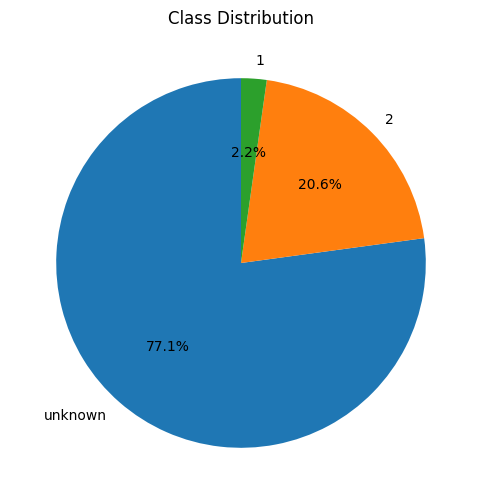

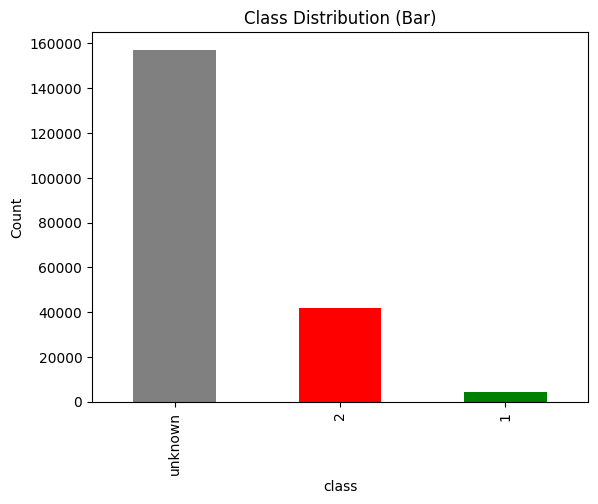

In [10]:
# Pie chart
plt.figure(figsize=(6,6))
data["class"].value_counts().plot(
    kind='pie', autopct='%1.1f%%', startangle=90
)
plt.title("Class Distribution")
plt.ylabel("")
plt.show()

# Bar chart
data["class"].value_counts().plot(
    kind='bar', color=['gray','red','green']
)
plt.title("Class Distribution (Bar)")
plt.ylabel("Count")
plt.show()

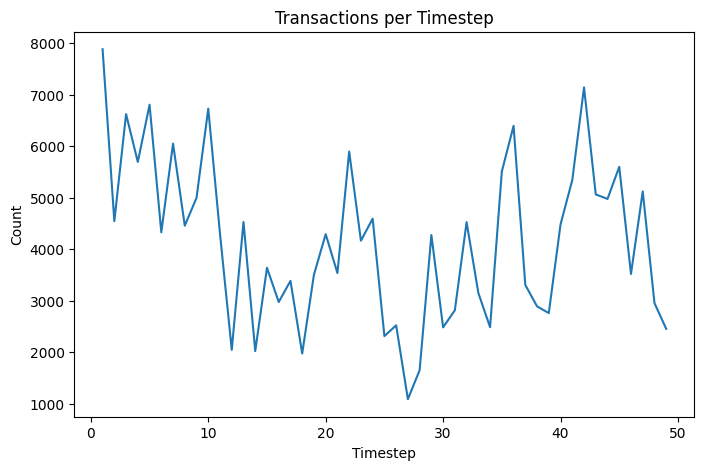

In [11]:
# Transactions per timestep
data.groupby("timestep").size().plot(figsize=(8,5))
plt.title("Transactions per Timestep")
plt.xlabel("Timestep")
plt.ylabel("Count")
plt.show()

/tmp/ipykernel_24/336253475.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_time['class'] = df_time['class'].replace({


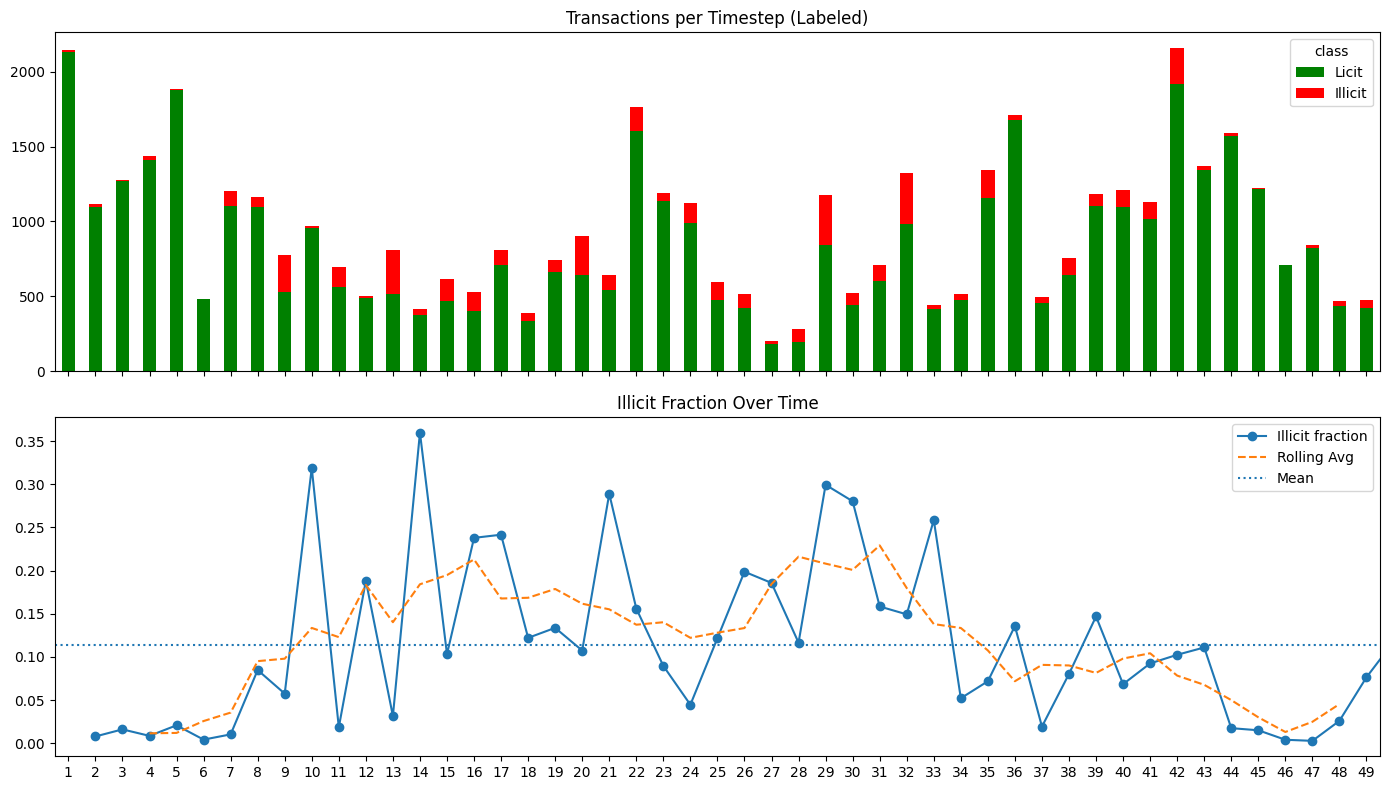

Max illicit fraction: 0.360 at step 13
Std deviation: 0.0949


In [12]:
df_time = data[['txId','timestep','class']].copy()

# Convert labels
df_time['class'] = df_time['class'].replace({
    'unknown': 0, '1': 1, '2': 2
}).astype(int)

tc = df_time.groupby(['timestep','class']).size().unstack(fill_value=0)
tc = tc.rename(columns={0:'Unknown', 1:'Illicit', 2:'Licit'})

# Illicit fraction
tc['illicit_frac'] = tc['Illicit'] / (tc['Illicit'] + tc['Licit']).replace(0, np.nan)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Bar plot
tc[['Licit','Illicit']].plot(
    kind='bar', stacked=True,
    color=['green','red'], ax=axes[0]
)
axes[0].set_title("Transactions per Timestep (Labeled)")

# Line plot
frac = tc['illicit_frac']
axes[1].plot(tc.index, frac, marker='o', label='Illicit fraction')
axes[1].plot(tc.index, frac.rolling(5,center=True).mean(),
             linestyle='--', label='Rolling Avg')
axes[1].axhline(frac.mean(), linestyle=':', label='Mean')

axes[1].set_title("Illicit Fraction Over Time")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Max illicit fraction: {frac.max():.3f} at step {frac.idxmax()}")
print(f"Std deviation: {frac.std():.4f}")

In [13]:
missing = data.isnull().sum()
print("Total missing:", missing.sum())
print(missing.sort_values(ascending=False).head())

Total missing: 0
txId        0
timestep    0
f_0         0
f_1         0
f_2         0
dtype: int64


In [14]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold()
selector.fit(data[feature_cols])

low_var = (selector.variances_ < 1e-5).sum()
print("Low variance features:", low_var)

Low variance features: 0


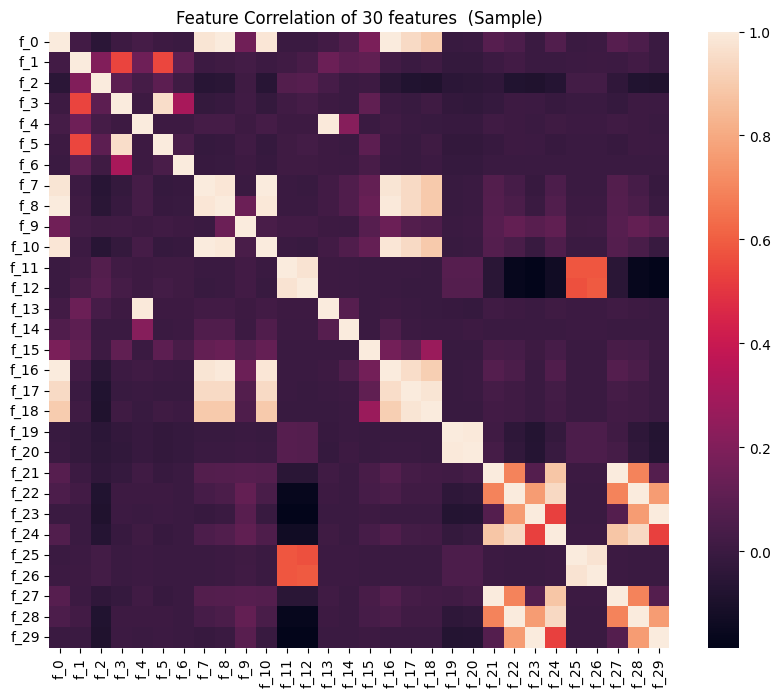

In [15]:
plt.figure(figsize=(10,8))
sns.heatmap(data[feature_cols[:30]].corr())
plt.title("Feature Correlation of 30 features  (Sample)")
plt.show()

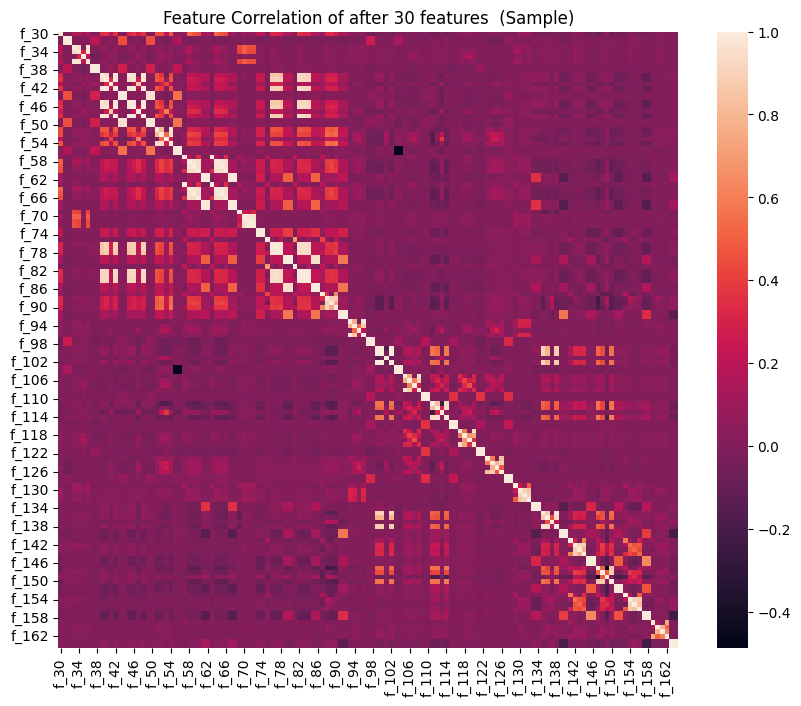

In [16]:
plt.figure(figsize=(10,8))
sns.heatmap(data[feature_cols[30:165]].corr())
plt.title("Feature Correlation of after 30 features  (Sample)")
plt.show()

In [17]:
df_labeled = data[data["class"] != "unknown"].copy()
df_labeled["class"] = df_labeled["class"].astype(int)

mean_ill = df_labeled[df_labeled["class"] == 1][feature_cols].mean()
mean_lic = df_labeled[df_labeled["class"] == 2][feature_cols].mean()

diff = (mean_ill - mean_lic).abs().sort_values(ascending=False)

print("\nTop 10 important features:")
print(diff.head(10))


Top 10 important features:
f_52    1.262973
f_54    1.082785
f_89    1.023468
f_88    1.000078
f_53    0.902200
f_51    0.853648
f_90    0.813541
f_58    0.753366
f_64    0.753319
f_59    0.707137
dtype: float64


In [18]:
G = nx.from_pandas_edgelist(
    edges,
    source="txId1",
    target="txId2",
    create_using=nx.DiGraph()
)

In [19]:
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())
print("Density:", nx.density(G))

Nodes: 203769
Edges: 234355
Density: 5.644170528459417e-06


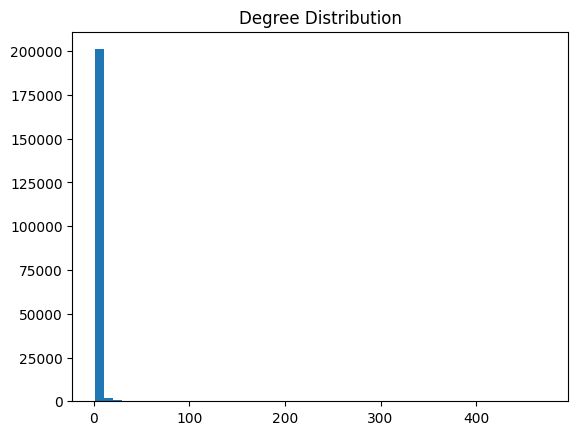

In [20]:
degrees = [d for n, d in G.degree()]

plt.hist(degrees, bins=50)
plt.title("Degree Distribution")
plt.show()

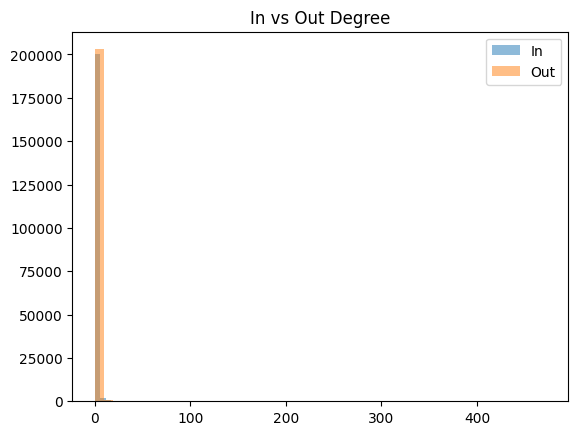

In [21]:
in_deg = [d for n, d in G.in_degree()]
out_deg = [d for n, d in G.out_degree()]

plt.hist(in_deg, bins=50, alpha=0.5, label='In')
plt.hist(out_deg, bins=50, alpha=0.5, label='Out')
plt.legend()
plt.title("In vs Out Degree")
plt.show()

In [22]:
components = list(nx.strongly_connected_components(G))
print("Strongly connected components:", len(components))

Strongly connected components: 203769


In [23]:
pagerank = nx.pagerank(G)

top_nodes = sorted(pagerank.items(), key=lambda x: x[1], reverse=True)[:10]
print("Top nodes by PageRank:", top_nodes)

Top nodes by PageRank: [(163832295, 0.0005267655724865401), (225859042, 0.0005207456704946088), (339157927, 0.0004847298083135419), (179084283, 0.00047383807255718305), (43388675, 0.0004700581104576359), (99409352, 0.00046059890623566843), (355176026, 0.0004308854870828579), (73405590, 0.0004102064048731097), (355110272, 0.000405721823791386), (91882349, 0.0004051140788208126)]


In [24]:
deg = dict(G.degree())
in_deg = dict(G.in_degree())
out_deg = dict(G.out_degree())

data["degree"] = data["txId"].map(deg)
data["in_degree"] = data["txId"].map(in_deg)
data["out_degree"] = data["txId"].map(out_deg)

In [25]:
data["in_out_ratio"] = data["in_degree"] / (data["out_degree"] + 1)

In [26]:
clustering = nx.clustering(G.to_undirected())
data["clustering"] = data["txId"].map(clustering)

In [27]:
pr = nx.pagerank(G)
data["pagerank"] = data["txId"].map(pr)

In [28]:
neighbor_deg = {}

for node in G.nodes():
    neighbors = list(G.neighbors(node))
    if len(neighbors) > 0:
        neighbor_deg[node] = np.mean([deg[n] for n in neighbors])
    else:
        neighbor_deg[node] = 0

data["neighbor_degree_mean"] = data["txId"].map(neighbor_deg)

In [29]:
tx_per_time = data.groupby("timestep").size()

data["activity_level"] = data["timestep"].map(tx_per_time)

In [30]:
illicit_ratio = (
    data[data["class"] == "1"]
    .groupby("timestep")
    .size() / data.groupby("timestep").size()
).fillna(0)

data["time_illicit_trend"] = data["timestep"].map(illicit_ratio)

In [31]:
data["degree_pagerank"] = data["degree"] * data["pagerank"]
data["in_degree_ratio"] = data["in_degree"] / (data["degree"] + 1)

In [32]:
# Original features
X_base = data.iloc[:, 2:167]

# New engineered features
new_features = [
    "degree", "in_degree", "out_degree",
    "in_out_ratio",
    "pagerank", "clustering",
    "neighbor_degree_mean",
    "activity_level", "time_illicit_trend",
    "degree_pagerank", "in_degree_ratio"
]

X_final = pd.concat([X_base, data[new_features]], axis=1)

print("Final feature shape:", X_final.shape)

Final feature shape: (203769, 176)


In [33]:
from networkx.algorithms import community

communities = community.greedy_modularity_communities(G)

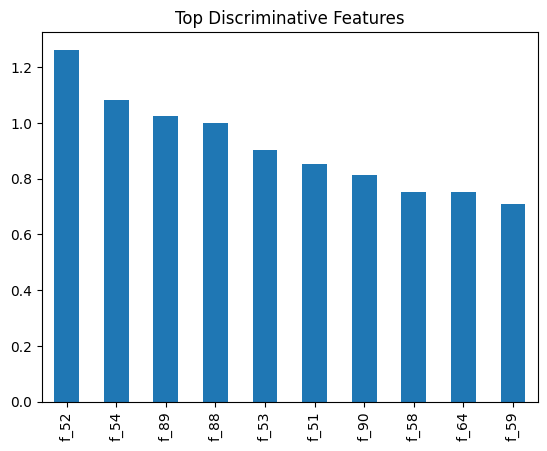

In [34]:
diff.head(10).plot(kind='bar')
plt.title("Top Discriminative Features")
plt.show()

In [35]:
import matplotlib.pyplot as plt

importance = model_new.feature_importances_

feature_names = X_new.columns

imp_df = pd.Series(importance, index=feature_names).sort_values(ascending=False)

imp_df.head(15).plot(kind='bar')
plt.title("Top Important Features")
plt.show()

NameError: name 'model_new' is not defined

In [ ]:
from sklearn.metrics import f1_score, average_precision_score
from xgboost import XGBClassifier

# Base features
X_base = data.iloc[:, 2:167]

# New features
X_new = X_final  # after adding engineered features

# Labels (remove unknown)
mask = data["class"] != "unknown"

y = data.loc[mask, "class"].astype(int)
y = y.replace({2: 0})  # licit = 0

# Split (temporal)
train_mask = data["timestep"] <= 30
test_mask  = data["timestep"] > 40

# ---------------------------
# TRAIN BASE MODEL
# ---------------------------
model_base = XGBClassifier(scale_pos_weight=10)

model_base.fit(X_base[mask & train_mask], y[train_mask[mask]])
pred_base = model_base.predict(X_base[mask & test_mask])
prob_base = model_base.predict_proba(X_base[mask & test_mask])[:,1]

# ---------------------------
# TRAIN NEW FEATURE MODEL
# ---------------------------
model_new = XGBClassifier(scale_pos_weight=10)

model_new.fit(X_new[mask & train_mask], y[train_mask[mask]])
pred_new = model_new.predict(X_new[mask & test_mask])
prob_new = model_new.predict_proba(X_new[mask & test_mask])[:,1]

# ---------------------------
# METRICS
# ---------------------------
print("BASE F1:", f1_score(y[test_mask[mask]], pred_base))
print("NEW  F1:", f1_score(y[test_mask[mask]], pred_new))

print("BASE PR-AUC:", average_precision_score(y[test_mask[mask]], prob_base))
print("NEW  PR-AUC:", average_precision_score(y[test_mask[mask]], prob_new))

In [ ]:
import matplotlib.pyplot as plt

importance = model_new.feature_importances_

feature_names = X_new.columns

imp_df = pd.Series(importance, index=feature_names).sort_values(ascending=False)

imp_df.head(15).plot(kind='bar')
plt.title("Top Important Features")
plt.show()